<a href="https://colab.research.google.com/github/Yuvraj5027/Generative-AI/blob/main/vae_mnist_latent_space_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAE on MNIST with a 2D latent space

In this notebook I build a Variational Autoencoder on MNIST with only 2 latent dimensions, so the whole latent space can be drawn on a normal x-y graph. I train it for 20 epochs, keep the reconstruction loss and the KL loss separate, and then look at how the digits are arranged in the latent space.

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

## Data

MNIST has 60,000 training images and 10,000 test images, each 28x28 pixels. `ToTensor()` scales the pixels to the range 0 to 1, which is what we want because the decoder will end with a sigmoid.

In [2]:
train_data = datasets.MNIST("data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST("data", train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.58MB/s]


## The model

A normal autoencoder turns each image into a single point. A VAE turns each image into a small Gaussian blob, so the encoder gives two things for each latent dimension: `mu` (the middle of the blob) and `logvar` (the log of its variance). We pick a random point `z` from that blob and the decoder tries to rebuild the image from `z`.

Picking a random point would block the gradients, so we use the reparameterization trick: `z = mu + std * eps`, where `eps` is random noise from a standard normal. The randomness is now in `eps`, and the network can still learn `mu` and `std`.

In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(784, 400)
        self.mu_layer = nn.Linear(400, 2)
        self.logvar_layer = nn.Linear(400, 2)
        self.decoder = nn.Sequential(
            nn.Linear(2, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = F.relu(self.hidden(x.view(-1, 784)))
        return self.mu_layer(h), self.logvar_layer(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        return self.decoder(z), mu, logvar


model = VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Training

The loss has two parts, and I keep them separate so they can be plotted.

- **Reconstruction loss**: how close the rebuilt image is to the original (binary cross entropy summed over the 784 pixels).
- **KL divergence**: how far the encoder's Gaussian is from a standard normal N(0, 1). For Gaussians the formula is `-0.5 * sum(1 + logvar - mu^2 - exp(logvar))`.

The two parts pull in opposite directions. Reconstruction wants every image to have its own separate spot, while KL wants everything squeezed near the centre. That balance is what makes the latent space smooth.

Each epoch I add up both losses and divide by the number of images, so the numbers are the average loss per image. The labels are not used in training.

In [5]:
recon_history = []
kl_history = []

for epoch in range(10):
    recon_total = 0
    kl_total = 0

    for images, _ in train_loader:
        recon_images, mu, logvar = model(images)

        recon_loss = F.binary_cross_entropy(recon_images, images.view(-1, 784), reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + logvar - mu ** 2 - torch.exp(logvar))
        loss = (recon_loss + kl_loss) / images.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        recon_total += recon_loss.item()
        kl_total += kl_loss.item()

    recon_history.append(recon_total / len(train_data))
    kl_history.append(kl_total / len(train_data))
    print(f"epoch {epoch + 1}: recon {recon_history[-1]:.2f}, kl {kl_history[-1]:.2f}")

epoch 1: recon 147.04, kl 5.82
epoch 2: recon 146.48, kl 5.85
epoch 3: recon 145.99, kl 5.88
epoch 4: recon 145.53, kl 5.91
epoch 5: recon 145.14, kl 5.91
epoch 6: recon 144.71, kl 5.94
epoch 7: recon 144.45, kl 5.97
epoch 8: recon 144.09, kl 5.99
epoch 9: recon 143.79, kl 6.02
epoch 10: recon 143.45, kl 6.02


## Loss curves

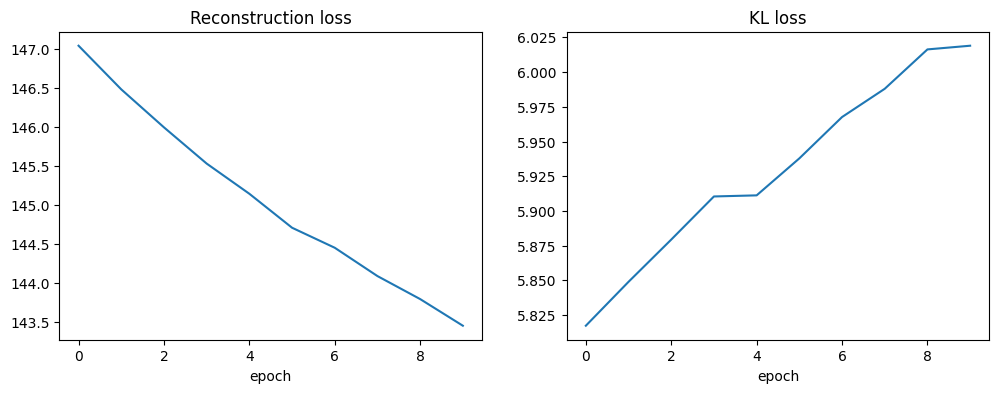

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(recon_history)
plt.title("Reconstruction loss")
plt.xlabel("epoch")

plt.subplot(1, 2, 2)
plt.plot(kl_history)
plt.title("KL loss")
plt.xlabel("epoch")

plt.savefig("loss_curves.png", dpi=150)
plt.show()

## Latent space of the test images

I pass all 10,000 test images through the encoder at once and use `mu` as the position of each image (no random sampling, so the plot is cleaner). Each point is coloured by its real digit label, which the model never saw during training.

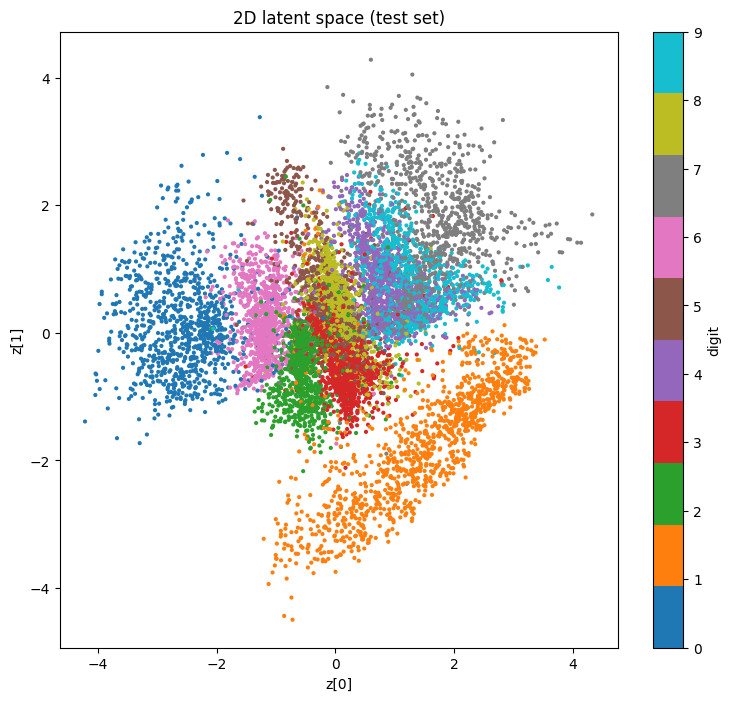

In [7]:
test_images = test_data.data.float() / 255
test_labels = test_data.targets

with torch.no_grad():
    mu, _ = model.encode(test_images)

plt.figure(figsize=(9, 8))
plt.scatter(mu[:, 0], mu[:, 1], c=test_labels, cmap="tab10", s=4)
plt.colorbar(ticks=range(10), label="digit")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("2D latent space (test set)")
plt.savefig("latent_scatter.png", dpi=150)
plt.show()

## Generating digits from the latent space

Now the other direction. I make a 15x15 grid of points between -3 and +3 and decode each one. None of these points come from a real image, so the decoder is generating new digits. The y values go from +3 at the top to -3 at the bottom so the picture matches the scatter plot.

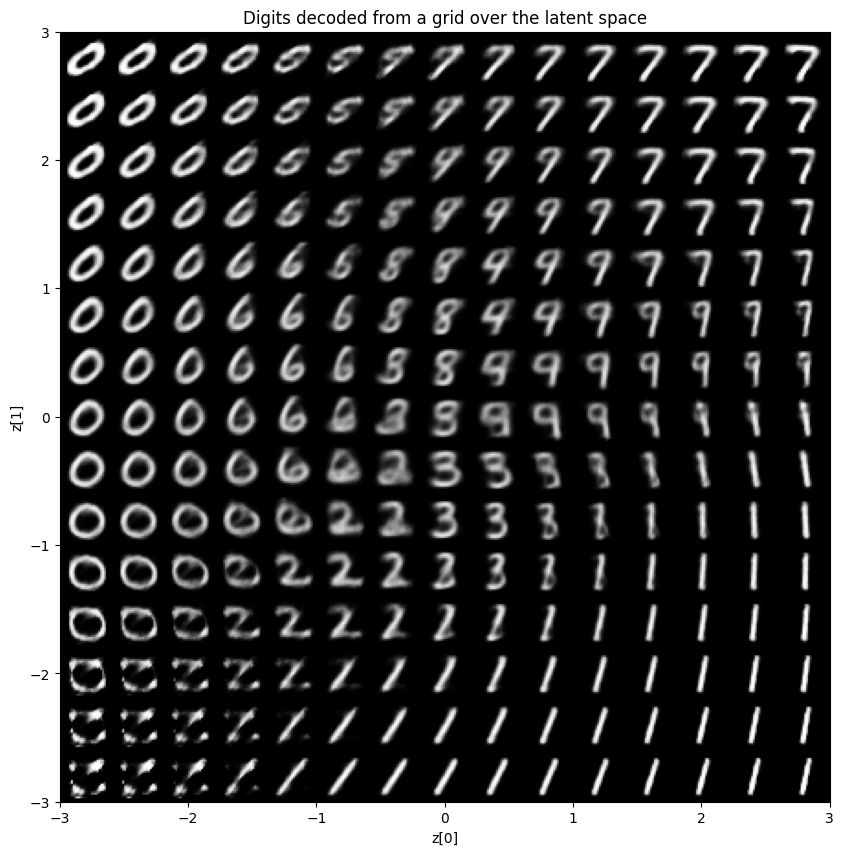

In [8]:
n = 15
z_values = np.linspace(-3, 3, n)
grid = np.zeros((n * 28, n * 28))

with torch.no_grad():
    for row, z1 in enumerate(reversed(z_values)):
        for col, z0 in enumerate(z_values):
            z = torch.tensor([[z0, z1]], dtype=torch.float32)
            digit = model.decoder(z).view(28, 28)
            grid[row * 28:(row + 1) * 28, col * 28:(col + 1) * 28] = digit.numpy()

plt.figure(figsize=(10, 10))
plt.imshow(grid, cmap="gray", extent=[-3, 3, -3, 3])
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Digits decoded from a grid over the latent space")
plt.savefig("decoded_grid.png", dpi=150)
plt.show()

## Observations

**Do similar digits form clusters?**
Yes. Even though the model never saw the labels, images of the same digit end up close to each other. Digits like 0, 1 and 6 are the easiest to spot as their own groups.

**Are the clusters clearly separated?**
Only partly. Some digits sit in their own area, but others overlap a lot. Digits that look alike, like 4, 7 and 9, or 3, 5 and 8, get mixed together. This makes sense because two dimensions is very little room to keep ten classes apart. The whole cloud also looks like one round blob around (0, 0) with hardly any empty gaps, which is the KL term doing its job.

**How do the generated digits change when moving through the latent space?**
They change slowly. Moving in one direction, one digit gradually bends into the next one, for example a 1 turning into a 7 and then into a 9. Things like slant and thickness also change bit by bit.

**Is the transition smooth?**
Mostly yes. Neighbouring points in the grid give very similar images and there are no sudden jumps. The exception is where two classes meet, where the digits get blurry or look like a mix of both. The generated images are also a bit blurrier than real MNIST digits, since each image is squeezed into just two numbers.

**Loss curves.**
The reconstruction loss drops fast in the first few epochs and then flattens out. The KL loss is much smaller than the reconstruction loss and stays low.